### Libraries

In [20]:
import torch
import open_clip
import json
import os
from PIL import Image
import matplotlib.pyplot as plt

### Load the data

In [2]:
with open("../data/dataset_rsicd.json", "r") as f:
    data = json.load(f)
    
data_a = [i for i in data["images"] if i["split"] == "train"]
data_b = [i for i in data["images"] if i["split"] == "val"]
data_c = [i for i in data["images"] if i["split"] == "test"]

### Load the model

A previously fine-tuned model checkpoint is loaded to evaluate performance on the test set.

In [3]:
model, _, preprocess = open_clip.create_model_and_transforms(
    'ViT-B-32',
    pretrained='openai'
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tokenizer = open_clip.get_tokenizer('ViT-B-32')
model.load_state_dict(torch.load("clip_rsicd.pt"))
model = model.to(device)

model.eval()

/nobackup/jonal155/clip_venv/lib/python3.10/site-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


CLIP(
  (visual): VisionTransformer(
    (conv1): Conv2d(3, 768, kernel_size=(32, 32), stride=(32, 32), bias=False)
    (patch_dropout): Identity()
    (ln_pre): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
    (transformer): Transformer(
      (resblocks): ModuleList(
        (0-11): 12 x ResidualAttentionBlock(
          (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          )
          (ls_1): Identity()
          (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (mlp): Sequential(
            (c_fc): Linear(in_features=768, out_features=3072, bias=True)
            (gelu): GELU(approximate='none')
            (c_proj): Linear(in_features=3072, out_features=768, bias=True)
          )
          (ls_2): Identity()
        )
      )
    )
    (ln_post): LayerNorm((768,), eps=1e-05, elementwise_affine

### Build retrieval test data

Lists are initialized to store evaluation data for the image-to-text retrieval task. test_images stores image file paths, test_captions stores all associated captions, and caption_to_image maintains a mapping from each caption to its corresponding image index. This mapping is required for evaluating retrieval accuracy.
\
\
For each image in split c, its file path is stored. Each image is associated with five captions, which are extracted and stored in a separate list. A parallel mapping is created to indicate which image each caption belongs to.

In [4]:
test_images = []
test_captions = []
caption_to_image = []

image_counter = 0

for img in data_c:
    image_path = f"../data/RSICD_images/{img['filename']}"

    if not os.path.exists(image_path):
        continue

    test_images.append(image_path)

    for sent in img["sentences"]:
        test_captions.append(sent["raw"])
        caption_to_image.append(image_counter)

    image_counter += 1

### Encode all images

Each test image is preprocessed and passed through the CLIP image encoder to obtain a feature embedding. The embeddings are normalized to unit length to ensure cosine similarity can be computed using dot products.
\
\
All image embeddings are concatenated into a single tensor representing the full test set in embedding space.

In [11]:
all_image_features = []

with torch.no_grad():
    for path in test_images:
        image = preprocess(Image.open(path)).unsqueeze(0).to(device)
        features = model.encode_image(image)
        features = features/features.norm(dim=-1, keepdim=True)
        all_image_features.append(features)

print(all_image_features)
all_image_features = torch.cat(all_image_features, dim=0)
print(all_image_features)
print(all_image_features.shape)


[tensor([[-3.1101e-02,  3.6175e-02,  3.2310e-03,  2.1919e-02, -2.1411e-02,
         -3.2127e-02,  3.0554e-02, -4.2345e-03, -6.7407e-03, -7.3452e-04,
         -6.2544e-03,  2.4069e-02,  4.9303e-02,  4.2421e-02, -1.3986e-02,
         -1.3948e-02, -7.9589e-03, -4.1606e-02, -5.0906e-02, -2.0379e-02,
          4.4019e-02, -1.1118e-02, -1.2226e-02, -7.7047e-03, -1.8731e-02,
          2.7200e-02, -1.1852e-02,  4.3919e-02, -1.5989e-02, -2.9002e-02,
          5.0327e-02, -2.4444e-02,  3.7954e-02,  5.6018e-02, -1.7052e-02,
          2.1673e-02,  7.5697e-03, -2.6850e-02,  5.8736e-03,  5.0511e-02,
          2.5476e-02, -1.8928e-02,  1.3577e-03,  1.1527e-02,  2.2010e-02,
         -9.3204e-02,  1.4747e-02,  2.7223e-02,  2.8361e-03, -1.1933e-02,
         -1.4305e-02,  1.3425e-02, -1.5001e-02,  2.9144e-02,  3.2319e-02,
          1.2101e-02, -2.5895e-02,  1.0274e-02,  3.4161e-02, -1.6751e-02,
          8.7952e-03, -2.4525e-02,  1.3863e-02, -1.8484e-02,  2.4664e-02,
          4.7185e-02, -2.8428e-02, -9

### Encode all captions

All captions in the test set are tokenized and passed through the CLIP text encoder to obtain their corresponding feature representations. As with image embeddings, the text embeddings are normalized to unit length. 
\
\
The resulting embeddings are also concatenated into a single tensor.

In [ ]:
all_text_features = []

with torch.no_grad():
    for caption in test_captions:
        tokens = tokenizer([caption]).to(device)
        
        features = model.encode_text(tokens)
        features = features/features.norm(dim=-1, keepdim=True)
        
        all_text_features.append(features)

all_text_features = torch.cat(all_text_features, dim=0)

### Similarity matrix

A similarity matrix is computed between all image embeddings and all text embeddings using a dot product. Since both embeddings are normalized, this operation is equivalent to cosine similarity. The resulting matrix represents how well each image matches each caption in the dataset.

In [13]:
similarity = all_image_features@all_text_features.T

### Recall@K evaluation

Retrieval performance is evaluated using Recall@K. For each query image, the top-K most similar captions are retrieved based on similarity scores. A retrieval is considered correct if at least one of the top-K captions belongs to the correct ground-truth image. The final score is computed as the proportion of correctly retrieved images over the entire test set.

In [14]:
def recall_at_k(similarity, caption_to_image, k=1):
    correct = 0
    for image_idx in range(similarity.shape[0]):
        sims = similarity[image_idx]
        topk = sims.topk(k).indices.cpu().numpy()
        retrieved_image_ids = [caption_to_image[i] for i in topk]

        if image_idx in retrieved_image_ids:
            correct += 1

    return correct/similarity.shape[0]

Retrieval performance is evaluated at multiple cutoff levels (K = 1, 5, and 10). These metrics measure how often the correct caption appears among the top-ranked retrieval results for each image.

In [15]:
r1 = recall_at_k(similarity, caption_to_image, k=1)
r5 = recall_at_k(similarity, caption_to_image, k=5)
r10 = recall_at_k(similarity, caption_to_image, k=10)

print(f"Recall@1: {r1:.4f}")
print(f"Recall@5: {r5:.4f}")
print(f"Recall@10: {r10:.4f}")

Recall@1: 0.0732
Recall@5: 0.1711
Recall@10: 0.2644


### Manual retrieval inspection

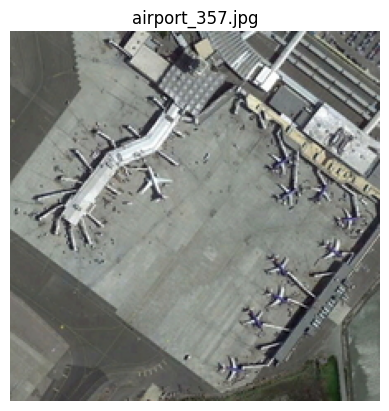

five aircrafts are staying on a square airport  with some buildings beside .


In [32]:
image_idx = 10

sims = similarity[image_idx]
topk = sims.topk(1).indices.cpu().numpy()

img = Image.open(test_images[image_idx])
plt.imshow(img)
plt.title(test_images[image_idx].split("/")[-1])
plt.axis("off")
plt.show()

for idx in topk:
    print(test_captions[idx])